# Phân tích hàng loạt dữ liệu tự đo (Custom Device) - Mô hình PIPELINE
Notebook này duyệt qua toàn bộ các file `.csv` trong thư mục `data/raw/new_data`, thực hiện tiền xử lý, trích xuất đặc trưng và dự đoán Rung tâm nhĩ (AFib) bằng mô hình Random Forest (huấn luyện trên MIMIC) cho từng file.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import joblib
from scipy.signal import find_peaks, butter, filtfilt, welch
from scipy.interpolate import interp1d

# Khởi tạo mô hình và scaler
# Khởi tạo mô hình Pipeline (đã gộp sẵn Scaler)
model_pipeline = joblib.load('../../models/mimic_afib_pipeline.pkl')

# Tìm tất cả các file csv trong new_data
data_path = '../../data/raw/new_data/*.csv'
file_list = glob.glob(data_path)
print(f"Tìm thấy {len(file_list)} file dữ liệu.")

Tìm thấy 5 file dữ liệu.


### 1. Định nghĩa các hàm Tiền xử lý & Trích xuất đặc trưng

In [2]:
def butter_bandpass_filter(data, lowcut=0.5, highcut=4.0, fs=125.0, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

def calculate_time_domain(rr_intervals):
    mean_nn = np.mean(rr_intervals)
    sdnn = np.std(rr_intervals, ddof=1)
    diff_nn = np.diff(rr_intervals)
    rmssd = np.sqrt(np.mean(diff_nn**2))
    nn50 = np.sum(np.abs(diff_nn) > 50)
    pnn50 = (nn50 / len(diff_nn)) * 100 if len(diff_nn) > 0 else 0
    cv = (sdnn / mean_nn) * 100 if mean_nn > 0 else np.nan
    return {'Mean_NN': mean_nn, 'SDNN': sdnn, 'RMSSD': rmssd, 'pNN50': pnn50, 'NN50': nn50, 'CV': cv}

def calculate_frequency_domain(rr_intervals, fs_interp=4.0):
    nan_res = {k: np.nan for k in ['LF', 'HF', 'LF_HF_Ratio', 'LF_norm', 'HF_norm', 'Total_Power']}
    if len(rr_intervals) < 10: return nan_res
    t = np.cumsum(rr_intervals) / 1000.0
    t -= t[0]
    try:
        f_interp = interp1d(t, rr_intervals / 1000.0, kind='cubic')
        t_interp = np.arange(t[0], t[-1], 1.0 / fs_interp)
        rr_interp = f_interp(t_interp)
    except: return nan_res
    nperseg = min(256, len(rr_interp))
    if nperseg < 2: return nan_res
    f, pxx = welch(rr_interp, fs=fs_interp, nperseg=nperseg)
    lf = np.sum(pxx[(f >= 0.04) & (f <= 0.15)]) * (f[1]-f[0])
    hf = np.sum(pxx[(f >= 0.15) & (f <= 0.4)]) * (f[1]-f[0])
    total_power = lf + hf
    return {'LF': lf, 'HF': hf, 'LF_HF_Ratio': lf/hf if hf>0 else np.nan, 'LF_norm': lf/total_power*100 if total_power>0 else np.nan, 'HF_norm': hf/total_power*100 if total_power>0 else np.nan, 'Total_Power': total_power}

### 2. Xử lý và Dự đoán toàn bộ các file


📦 XỬ LÝ FILE: do_20260715_203009_session1.csv


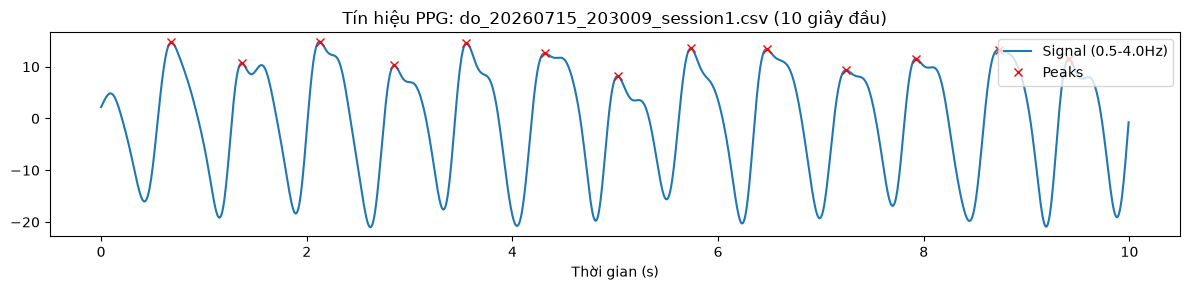

   - Nhịp tim (HR): 81 BPM
   - Độ biến thiên (SDNN): 56.18 ms
   - Tỉ lệ LF/HF: 0.10


👉 KẾT LUẬN: ✅ BÌNH THƯỜNG (Độ tin cậy: 58.0%)

📦 XỬ LÝ FILE: do_20260715_203139_session2.csv


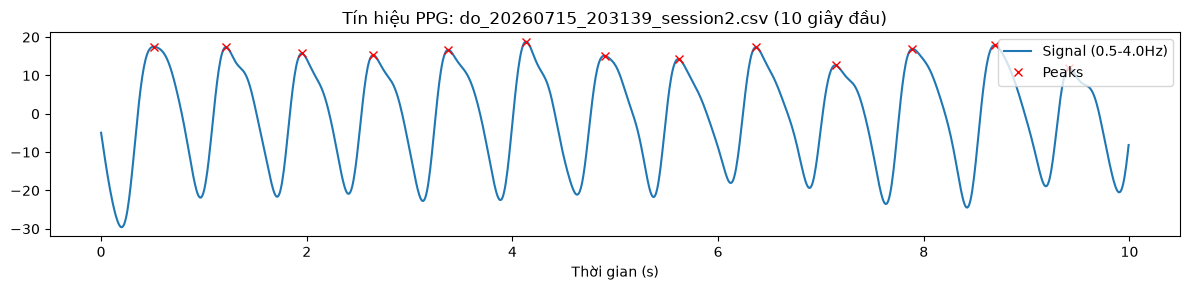

   - Nhịp tim (HR): 82 BPM
   - Độ biến thiên (SDNN): 36.47 ms
   - Tỉ lệ LF/HF: 0.44


👉 KẾT LUẬN: ✅ BÌNH THƯỜNG (Độ tin cậy: 84.0%)

📦 XỬ LÝ FILE: do_20260715_203309_session3.csv


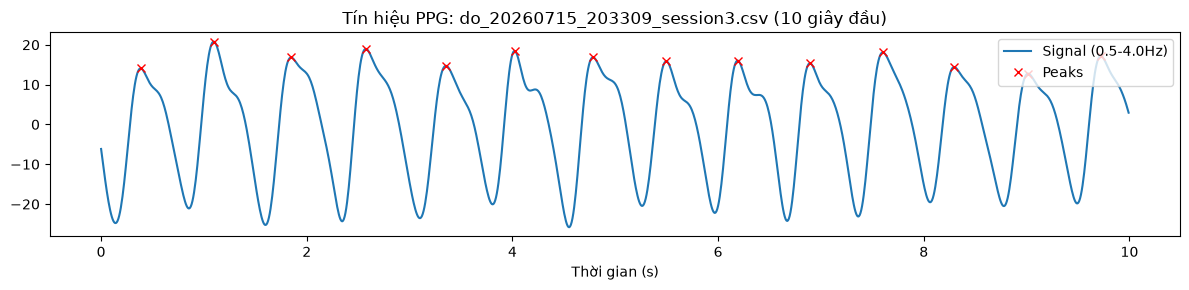

   - Nhịp tim (HR): 86 BPM
   - Độ biến thiên (SDNN): 37.25 ms
   - Tỉ lệ LF/HF: 1.10


👉 KẾT LUẬN: ✅ BÌNH THƯỜNG (Độ tin cậy: 100.0%)

📦 XỬ LÝ FILE: do_20260715_203439_session4.csv


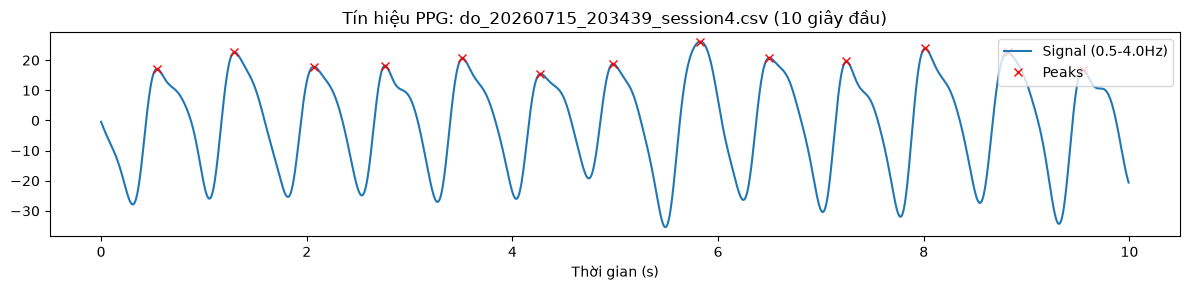

   - Nhịp tim (HR): 81 BPM
   - Độ biến thiên (SDNN): 36.31 ms
   - Tỉ lệ LF/HF: 0.20


👉 KẾT LUẬN: ✅ BÌNH THƯỜNG (Độ tin cậy: 76.0%)

📦 XỬ LÝ FILE: do_20260715_203609_session5.csv


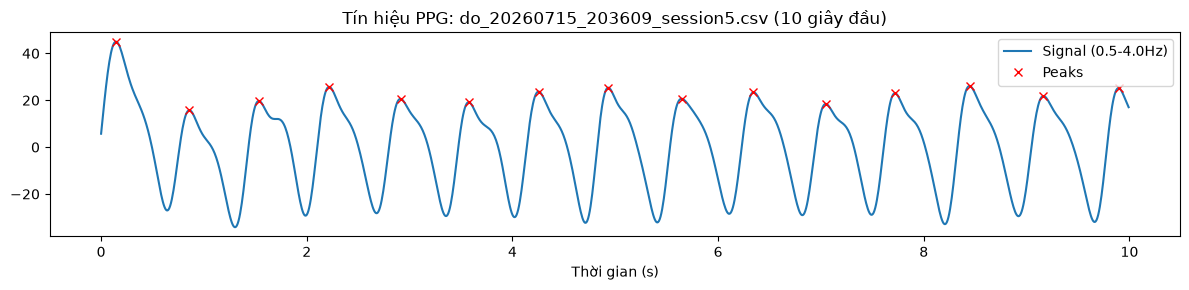

   - Nhịp tim (HR): 85 BPM
   - Độ biến thiên (SDNN): 30.15 ms
   - Tỉ lệ LF/HF: 0.93


👉 KẾT LUẬN: ✅ BÌNH THƯỜNG (Độ tin cậy: 100.0%)


In [3]:
for file in sorted(file_list):
    filename = os.path.basename(file)
    print(f"\n{'='*60}")
    print(f"📦 XỬ LÝ FILE: {filename}")
    print(f"{'='*60}")
    
    # 1. Đọc dữ liệu
    df = pd.read_csv(file)
    if len(df) == 0:
        print("File rỗng!")
        continue
        
    # 2. Cắt 3 giây đầu
    start_time_ms = df['Time(ms)'].iloc[0]
    valid_df = df[df['Time(ms)'] > start_time_ms + 3000].copy()
    valid_df['Time(s)'] = (valid_df['Time(ms)'] - start_time_ms - 3000) / 1000.0
    valid_df = valid_df.drop_duplicates(subset=['Time(s)'])
    
    time_s = valid_df['Time(s)'].values
    ir_signal = valid_df['IR'].values
    
    # 3. Nghịch đảo và Nội suy 125Hz
    inverted_ir = -ir_signal
    new_time_s = np.arange(0, time_s[-1], 1.0 / 125.0)
    interpolator = interp1d(time_s, inverted_ir, kind='cubic', fill_value='extrapolate')
    resampled_ir = interpolator(new_time_s)
    
    # 4. Lọc Bandpass (0.5 - 4.0 Hz)
    clean_ir = butter_bandpass_filter(resampled_ir, fs=125.0)
    
    # 5. Dò tìm đỉnh
    peaks, _ = find_peaks(clean_ir, distance=int(0.25 * 125.0), prominence=np.std(clean_ir)*0.5)
    
    # Vẽ biểu đồ nhanh (lấy 10 giây đầu)
    mask_10s = new_time_s < 10.0
    peaks_10s = peaks[new_time_s[peaks] < 10.0]
    
    plt.figure(figsize=(12, 3))
    plt.plot(new_time_s[mask_10s], clean_ir[mask_10s], label='Signal (0.5-4.0Hz)')
    plt.plot(new_time_s[peaks_10s], clean_ir[peaks_10s], 'rx', label='Peaks')
    plt.title(f'Tín hiệu PPG: {filename} (10 giây đầu)')
    plt.xlabel('Thời gian (s)')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
    
    # 6. Tính khoảng R-R và lọc sinh lý
    peak_times = new_time_s[peaks]
    rr_intervals = np.diff(peak_times) * 1000.0
    valid_rr = rr_intervals[(rr_intervals >= 300) & (rr_intervals <= 2000)]
    
    if len(valid_rr) < 10:
        print("⚠️ Quá nhiều nhiễu hoặc không đủ nhịp tim hợp lệ để tính toán.")
        continue
        
    # 7. Tính 13 đặc trưng
    features = {'HR_mean': 60000.0 / np.mean(valid_rr)}
    features.update(calculate_time_domain(valid_rr))
    features.update(calculate_frequency_domain(valid_rr))
    
    for k in features:
        if pd.isna(features[k]): features[k] = 0.0
        
    print(f"   - Nhịp tim (HR): {features['HR_mean']:.0f} BPM")
    print(f"   - Độ biến thiên (SDNN): {features['SDNN']:.2f} ms")
    print(f"   - Tỉ lệ LF/HF: {features['LF_HF_Ratio']:.2f}\n")
    
    # 8. Dự đoán
    features_df = pd.DataFrame([features])
    
    pred = model_pipeline.predict(features_df)[0]
    prob = model_pipeline.predict_proba(features_df)[0]
    
    if pred == 1:
        print(f"\n👉 KẾT LUẬN: ⚠️ PHÁT HIỆN RUNG TÂM NHĨ (AFib) (Độ tin cậy: {prob[1]*100:.1f}%)")
    else:
        print(f"\n👉 KẾT LUẬN: ✅ BÌNH THƯỜNG (Độ tin cậy: {prob[0]*100:.1f}%)")
